<a href="https://colab.research.google.com/github/mahidhargubbala-pixel/student-performance-analysis/blob/main/student_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance - Data Cleaning & Visualization Project

Tools used: Python, Pandas, Matplotlib, Seaborn

What I did:
- Removed duplicates
- Fixed inconsistent Gender values
- Handled Age outliers
- Imputed missing values with median/mode
- Created AverageScore, Grade, PassFail columns
- Visualized distributions, grades, correlations, attendance

In [1]:
# Install seaborn if needed
!pip install seaborn

# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Create raw messy student dataset
np.random.seed(42)
n = 200

data = {
    "StudentID": [f"S{str(i).zfill(3)}" for i in range(1, n+1)],
    "Gender": np.random.choice(
        ["Male","Female","male","FEMALE","M","F", None], n,
        p=[0.35, 0.35, 0.07, 0.07, 0.05, 0.05, 0.06]
    ),
    "Age": np.random.choice(
        list(range(15, 22)) + [99, -1, None], n,
        p=[0.13,0.13,0.13,0.12,0.12,0.12,0.12,0.04,0.04,0.05]
    ),
    "MathScore":    np.where(np.random.rand(n) < 0.06, None, np.random.randint(30, 101, n)),
    "ScienceScore": np.where(np.random.rand(n) < 0.05, None, np.random.randint(25, 101, n)),
    "EnglishScore": np.where(np.random.rand(n) < 0.07, None, np.random.randint(20, 101, n)),
    "Attendance":   np.where(np.random.rand(n) < 0.04, None, np.random.randint(50, 101, n)),
    "StudyHours":   np.where(np.random.rand(n) < 0.05, None, np.round(np.random.uniform(0.5, 8, n), 1)),
    "ParentalEdu":  np.random.choice(
        ["High School","Bachelor","Master","PhD", None], n,
        p=[0.30, 0.35, 0.20, 0.10, 0.05]
    ),
}

df = pd.DataFrame(data)

# Add 2 duplicate rows on purpose
df = pd.concat([df, df.iloc[[5, 10]]], ignore_index=True)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (202, 9)

First 5 rows:


,StudentID,Gender,Age,MathScore,ScienceScore,EnglishScore,Attendance,StudyHours,ParentalEdu
0,S001,Female,20,34,46,50,77,1.9,Bachelor
1,S002,None,15,71,93,77,62,3.0,High School
2,S003,male,16,90,80,80,80,2.8,PhD
3,S004,Female,99,51,57,43,63,7.6,PhD
4,S005,Male,19,50,60,39,69,7.8,Bachelor


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
StudentID        0
Gender          10
Age             10
MathScore       13
ScienceScore    13
EnglishScore    18
Attendance       5
StudyHours      12
ParentalEdu      8
dtype: int64


In [4]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape: (202, 9)

Data types:
StudentID       object
Gender          object
Age             object
MathScore       object
ScienceScore    object
EnglishScore    object
Attendance      object
StudyHours      object
ParentalEdu     object
dtype: object


In [5]:
print("Unique Gender values:")
print(df["Gender"].unique())

Unique Gender values:
['Female' None 'male' 'Male' 'M' 'FEMALE' 'F']


In [6]:
print("Age min:", df["Age"].min())
print("Age max:", df["Age"].max())
print("Age value counts:")
print(df["Age"].value_counts().sort_index())

Age min: -1
Age max: 99
Age value counts:
Age
-1     8
15    33
16    18
17    26
18    18
19    27
20    31
21    25
99     6
Name: count, dtype: int64


In [7]:
print("Before:", df.shape)
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

Before: (202, 9)
After removing duplicates: (200, 9)


In [8]:
gender_map = {"male": "Male", "FEMALE": "Female", "M": "Male", "F": "Female"}
df["Gender"] = df["Gender"].replace(gender_map)

# Replace anything not Male/Female with NaN
df["Gender"] = df["Gender"].where(df["Gender"].isin(["Male", "Female"]), other=np.nan)

print("Gender values now:")
print(df["Gender"].value_counts())

Gender values now:
Gender
Male      101
Female     89
Name: count, dtype: int64


In [9]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Replace impossible ages with NaN
df.loc[~df["Age"].between(10, 25), "Age"] = np.nan

print("Age range now:", df["Age"].min(), "to", df["Age"].max())

Age range now: 15.0 to 21.0


In [10]:
num_cols = ["MathScore", "ScienceScore", "EnglishScore", "Attendance", "StudyHours", "Age"]

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val).round(1)

print("Missing values after fix:")
print(df[num_cols].isnull().sum())

Missing values after fix:
MathScore       0
ScienceScore    0
EnglishScore    0
Attendance      0
StudyHours      0
Age             0
dtype: int64


/tmp/ipykernel_4419/427703358.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(median_val).round(1)
/tmp/ipykernel_4419/427703358.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(median_val).round(1)
/tmp/ipykernel_4419/427703358.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df

In [11]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["ParentalEdu"] = df["ParentalEdu"].fillna(df["ParentalEdu"].mode()[0])

print("All missing values now:")
print(df.isnull().sum())

All missing values now:
StudentID       0
Gender          0
Age             0
MathScore       0
ScienceScore    0
EnglishScore    0
Attendance      0
StudyHours      0
ParentalEdu     0
dtype: int64


In [12]:
df["AverageScore"] = df[["MathScore", "ScienceScore", "EnglishScore"]].mean(axis=1).round(2)

print("Average Score added!")
print(df["AverageScore"].describe())

Average Score added!
count    200.000000
mean      62.233050
std       12.258731
min       29.000000
25%       53.790000
50%       61.330000
75%       71.542500
max       89.330000
Name: AverageScore, dtype: float64


In [13]:
df["Grade"] = pd.cut(df["AverageScore"],
    bins=[0, 39, 49, 59, 69, 79, 89, 100],
    labels=["F", "D", "C-", "C", "B", "A-", "A"])

print("Grade distribution:")
print(df["Grade"].value_counts().sort_index())

Grade distribution:
Grade
F      4
D     26
C-    54
C     52
B     42
A-    21
A      1
Name: count, dtype: int64


In [14]:
df["PassFail"] = df["AverageScore"].apply(lambda x: "Pass" if x >= 50 else "Fail")

print("Pass/Fail count:")
print(df["PassFail"].value_counts())

Pass/Fail count:
PassFail
Pass    166
Fail     34
Name: count, dtype: int64


In [15]:
print("Final dataset shape:", df.shape)
df.head(10)

Final dataset shape: (200, 12)


,StudentID,Gender,Age,MathScore,ScienceScore,EnglishScore,Attendance,StudyHours,ParentalEdu,AverageScore,Grade,PassFail
0,S001,Female,20.0,34.0,46.0,50.0,77.0,1.9,Bachelor,43.33,D,Fail
1,S002,Male,15.0,71.0,93.0,77.0,62.0,3.0,High School,80.33,A-,Pass
2,S003,Male,16.0,90.0,80.0,80.0,80.0,2.8,PhD,83.33,A-,Pass
3,S004,Female,18.0,51.0,57.0,43.0,63.0,7.6,PhD,50.33,C-,Pass
4,S005,Male,19.0,50.0,60.0,39.0,69.0,7.8,Bachelor,49.67,C-,Fail
5,S006,Male,15.0,99.0,44.0,56.0,67.0,1.9,Bachelor,66.33,C,Pass
6,S007,Male,15.0,30.0,86.0,23.0,78.0,4.0,Bachelor,46.33,D,Fail
7,S008,Male,20.0,63.0,97.0,39.0,55.0,5.9,Bachelor,66.33,C,Pass
8,S009,Female,15.0,41.0,50.0,79.0,81.0,3.6,Bachelor,56.67,C-,Pass
9,S010,Male,16.0,75.0,90.0,43.0,78.0,1.2,Master,69.33,B,Pass


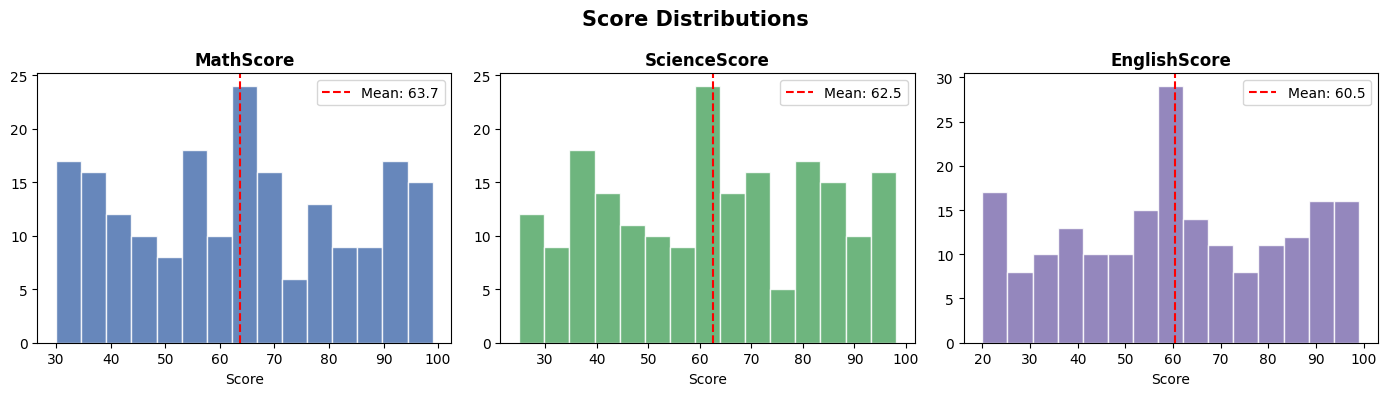

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes,
    ["MathScore", "ScienceScore", "EnglishScore"],
    ["#4C72B0", "#55A868", "#8172B2"]):

    ax.hist(df[col], bins=15, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.1f}")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Score")
    ax.legend()

plt.suptitle("Score Distributions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

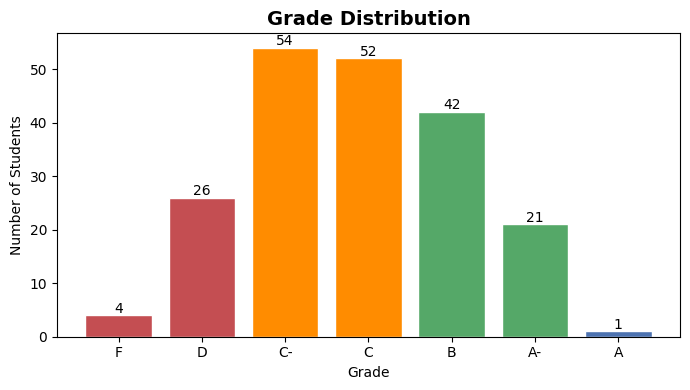

In [17]:
grade_counts = df["Grade"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(grade_counts.index.astype(str), grade_counts.values,
        color=["#C44E52","#C44E52","#FF8C00","#FF8C00","#55A868","#55A868","#4C72B0"],
        edgecolor="white")

for i, val in enumerate(grade_counts.values):
    plt.text(i, val + 0.5, str(val), ha="center", fontsize=10)

plt.title("Grade Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

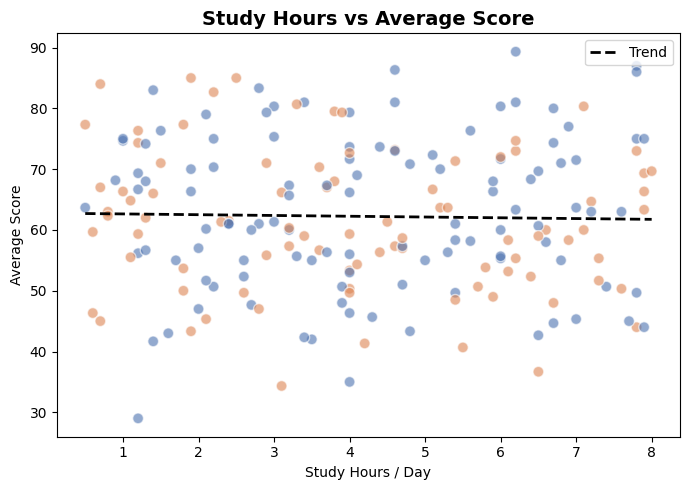

In [18]:
plt.figure(figsize=(7, 5))

colors = df["Gender"].map({"Male": "#4C72B0", "Female": "#DD8452"})
plt.scatter(df["StudyHours"], df["AverageScore"],
            c=colors, alpha=0.6, edgecolors="white", s=60)

# Trend line
m, b = np.polyfit(df["StudyHours"].astype(float), df["AverageScore"].astype(float), 1)
x = np.linspace(df["StudyHours"].min(), df["StudyHours"].max(), 100)
plt.plot(x, m*x + b, color="black", linestyle="--", linewidth=2, label="Trend")

plt.title("Study Hours vs Average Score", fontsize=14, fontweight="bold")
plt.xlabel("Study Hours / Day")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.show()

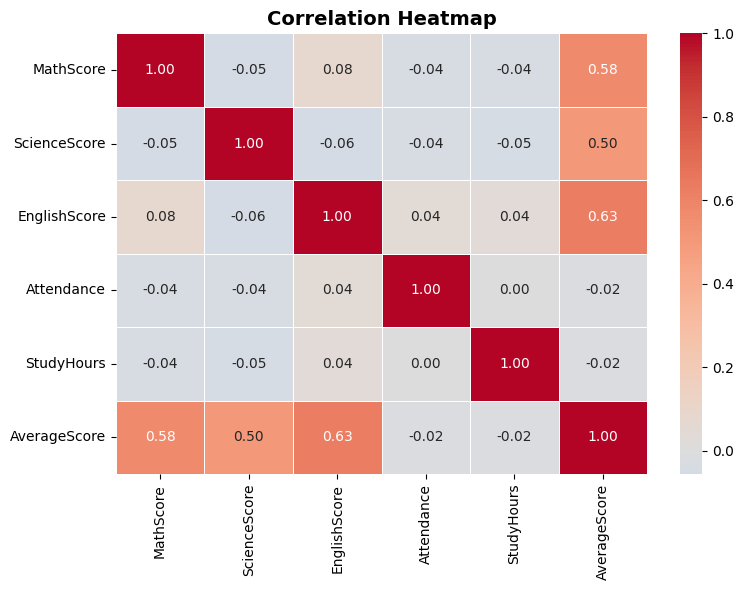

In [19]:
plt.figure(figsize=(8, 6))

corr = df[["MathScore","ScienceScore","EnglishScore",
           "Attendance","StudyHours","AverageScore"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4419/433474418.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="AttendanceBand", y="AverageScore",


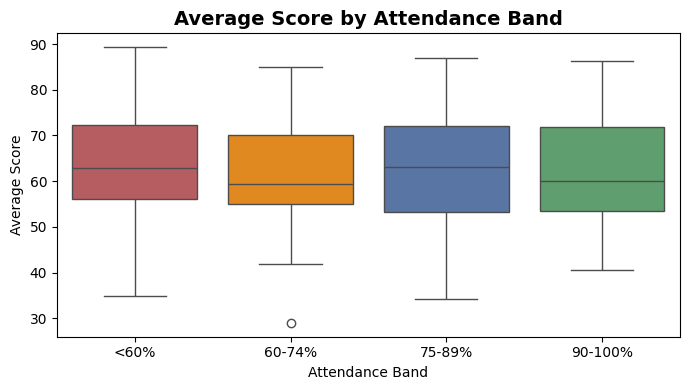

In [20]:
df["AttendanceBand"] = pd.cut(df["Attendance"],
    bins=[0, 59, 74, 89, 100],
    labels=["<60%", "60-74%", "75-89%", "90-100%"])

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="AttendanceBand", y="AverageScore",
            palette=["#C44E52","#FF8C00","#4C72B0","#55A868"])

plt.title("Average Score by Attendance Band", fontsize=14, fontweight="bold")
plt.xlabel("Attendance Band")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()

In [21]:
df.to_csv("cleaned_student_data.csv", index=False)
print("✅ CSV saved!")

✅ CSV saved!


In [22]:
print("=" * 40)
print("   STUDENT PERFORMANCE SUMMARY")
print("=" * 40)
print(f"Total Students   : {len(df)}")
print(f"Pass Rate        : {(df['PassFail']=='Pass').mean()*100:.1f}%")
print(f"Avg Math Score   : {df['MathScore'].mean():.1f}")
print(f"Avg Science Score: {df['ScienceScore'].mean():.1f}")
print(f"Avg English Score: {df['EnglishScore'].mean():.1f}")
print(f"Avg Study Hours  : {df['StudyHours'].mean():.1f} hrs/day")
print("=" * 40)
print("\nGrade Distribution:")
print(df["Grade"].value_counts().sort_index())

   STUDENT PERFORMANCE SUMMARY
Total Students   : 200
Pass Rate        : 83.0%
Avg Math Score   : 63.7
Avg Science Score: 62.5
Avg English Score: 60.5
Avg Study Hours  : 4.2 hrs/day

Grade Distribution:
Grade
F      4
D     26
C-    54
C     52
B     42
A-    21
A      1
Name: count, dtype: int64
